#Training YOLOv8 Object Detection for the FAIR-Device Fairtrack tracking system

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/jach999/fairtrack)

Ultralytics YOLOv8 is the latest version of the YOLO (You Only Look Once) object detection and image segmentation model developed by Ultralytics. The YOLOv8 model is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and image segmentation tasks. It can be trained on large datasets and is capable of running on a variety of hardware platforms, from CPUs to GPUs.

## Steps in this Training Script

In this script, we are going to cover:

- Install YOLOv8
- Import Roboflow Dataset
- Custom Training
- Validate Custom Model
- Inference with Custom Model


In [ ]:
import os

#%cd /home
#os.makedirs('/home/fairtrack_training', exist_ok=True)
#print("Folder '/home/fairtrack_training' created successfully.")

HOME = os.getcwd()
print(HOME)

/content
/content


## Before Starting: Checking GPU Access and Memory Availability

In [ ]:
# Test if GPU is available

!nvidia-smi

import torch
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    print(f"CUDA is available! GPU: {device_name}")
else:
    print("CUDA is not available. Calculations are performed on CPU.")

Tue Mar 25 15:18:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Check the available memory on the system:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       6.5Gi       1.0Mi       5.1Gi        11Gi
Swap:             0B          0B          0B


In [ ]:
# Check the number of CPU cores
import multiprocessing

num_workers = multiprocessing.cpu_count()
print(f"Number of CPU Cores: {num_workers}")

Number of CPU Cores: 2


In [ ]:
# Check the available shared memory (shm) on system
!df -h /dev/shm


Filesystem      Size  Used Avail Use% Mounted on
shm             5.7G     0  5.7G   0% /dev/shm


## Install YOLOv8

⚠️ YOLOv8 is still under heavy development. Breaking changes are being introduced almost weekly. We strive to make our YOLOv8 notebooks work with the latest version of the library. Last tests took place on **18.01.2023** with version **YOLOv8.0.9**.

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [ ]:
#!apt-get update
#!apt-get install -y libgl1-mesa-glx

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,380 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,698 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,767 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [3,813 kB]
Hit:13 https://ppa.lau

In [ ]:
# Pip install method (recommended)

!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.2/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!pip install pickleshare

## Import Roboflow Dataset

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://v8docs.ultralytics.com/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

In [ ]:
import os

!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="XXXX") # A private key that is tied to your Roboflow account
project = rf.workspace("fairdevice-zetpx").project("fair-d_v2.5-ki4ty")
version = project.version(1)
dataset = version.download("yolov8")


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FAIR-D_V2.5-2 in yolov8:: 100%|██████████| 42864/42864 [00:06<00:00, 6917.88it/s]


In [ ]:
import yaml

data_yaml_path = f'{HOME}/datasets/FAIR-D_V2.5-1/data.yaml'
data = None

# Read the existing data.yaml
with open(data_yaml_path, 'r') as file:
    data = yaml.safe_load(file)

# Update paths
data['train'] = f'{HOME}/datasets/FAIR-D_V2.5-1/train/images'
data['val'] = f'{HOME}/datasets/FAIR-D_V2.5-1/valid/images'
data['test'] = f'{HOME}/datasets/FAIR-D_V2.5-1/test/images'

# Write the updated data back to data.yaml
with open(data_yaml_path, 'w') as file:
    yaml.safe_dump(data, file)

print("Updated data.yaml with correct paths.")


Updated data.yaml with correct paths.


In [ ]:
import os

# Check if the dataset path is correct
directory_path = f'{HOME}/datasets/FAIR-D_V2.5-1'

if os.path.exists(directory_path):
    print(f"The directory '{directory_path}' exists.")
else:
    print(f"The directory '{directory_path}' does not exist.")


The directory '/content/datasets/FAIR-D_V2.5-2' exists.


# Custom Training

## Model training

In [ ]:
import os
import shutil

# Training setup
num_epochs = 300
image_size = 640
model = "yolov8s.pt"
dataset_location = f'{HOME}/datasets/FAIR-D_V2.5-1'

# Change directory to HOME
%cd {HOME}

# Ensure the 'runs' and 'runs/detect' folders exist
os.makedirs(f'{HOME}/runs/detect', exist_ok=True)

# YOLO training command
yolo_train = f"yolo task=detect mode=train model={model} data={dataset_location}/data.yaml epochs={num_epochs} imgsz={image_size} plots=True workers=4"

# Running the YOLO command
!{yolo_train}


/content
/content
Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/FAIR-D_V2.5-2/data.yaml, epochs=1, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels

## Training Results

/content/runs/detect/train2/confusion_matrix.png


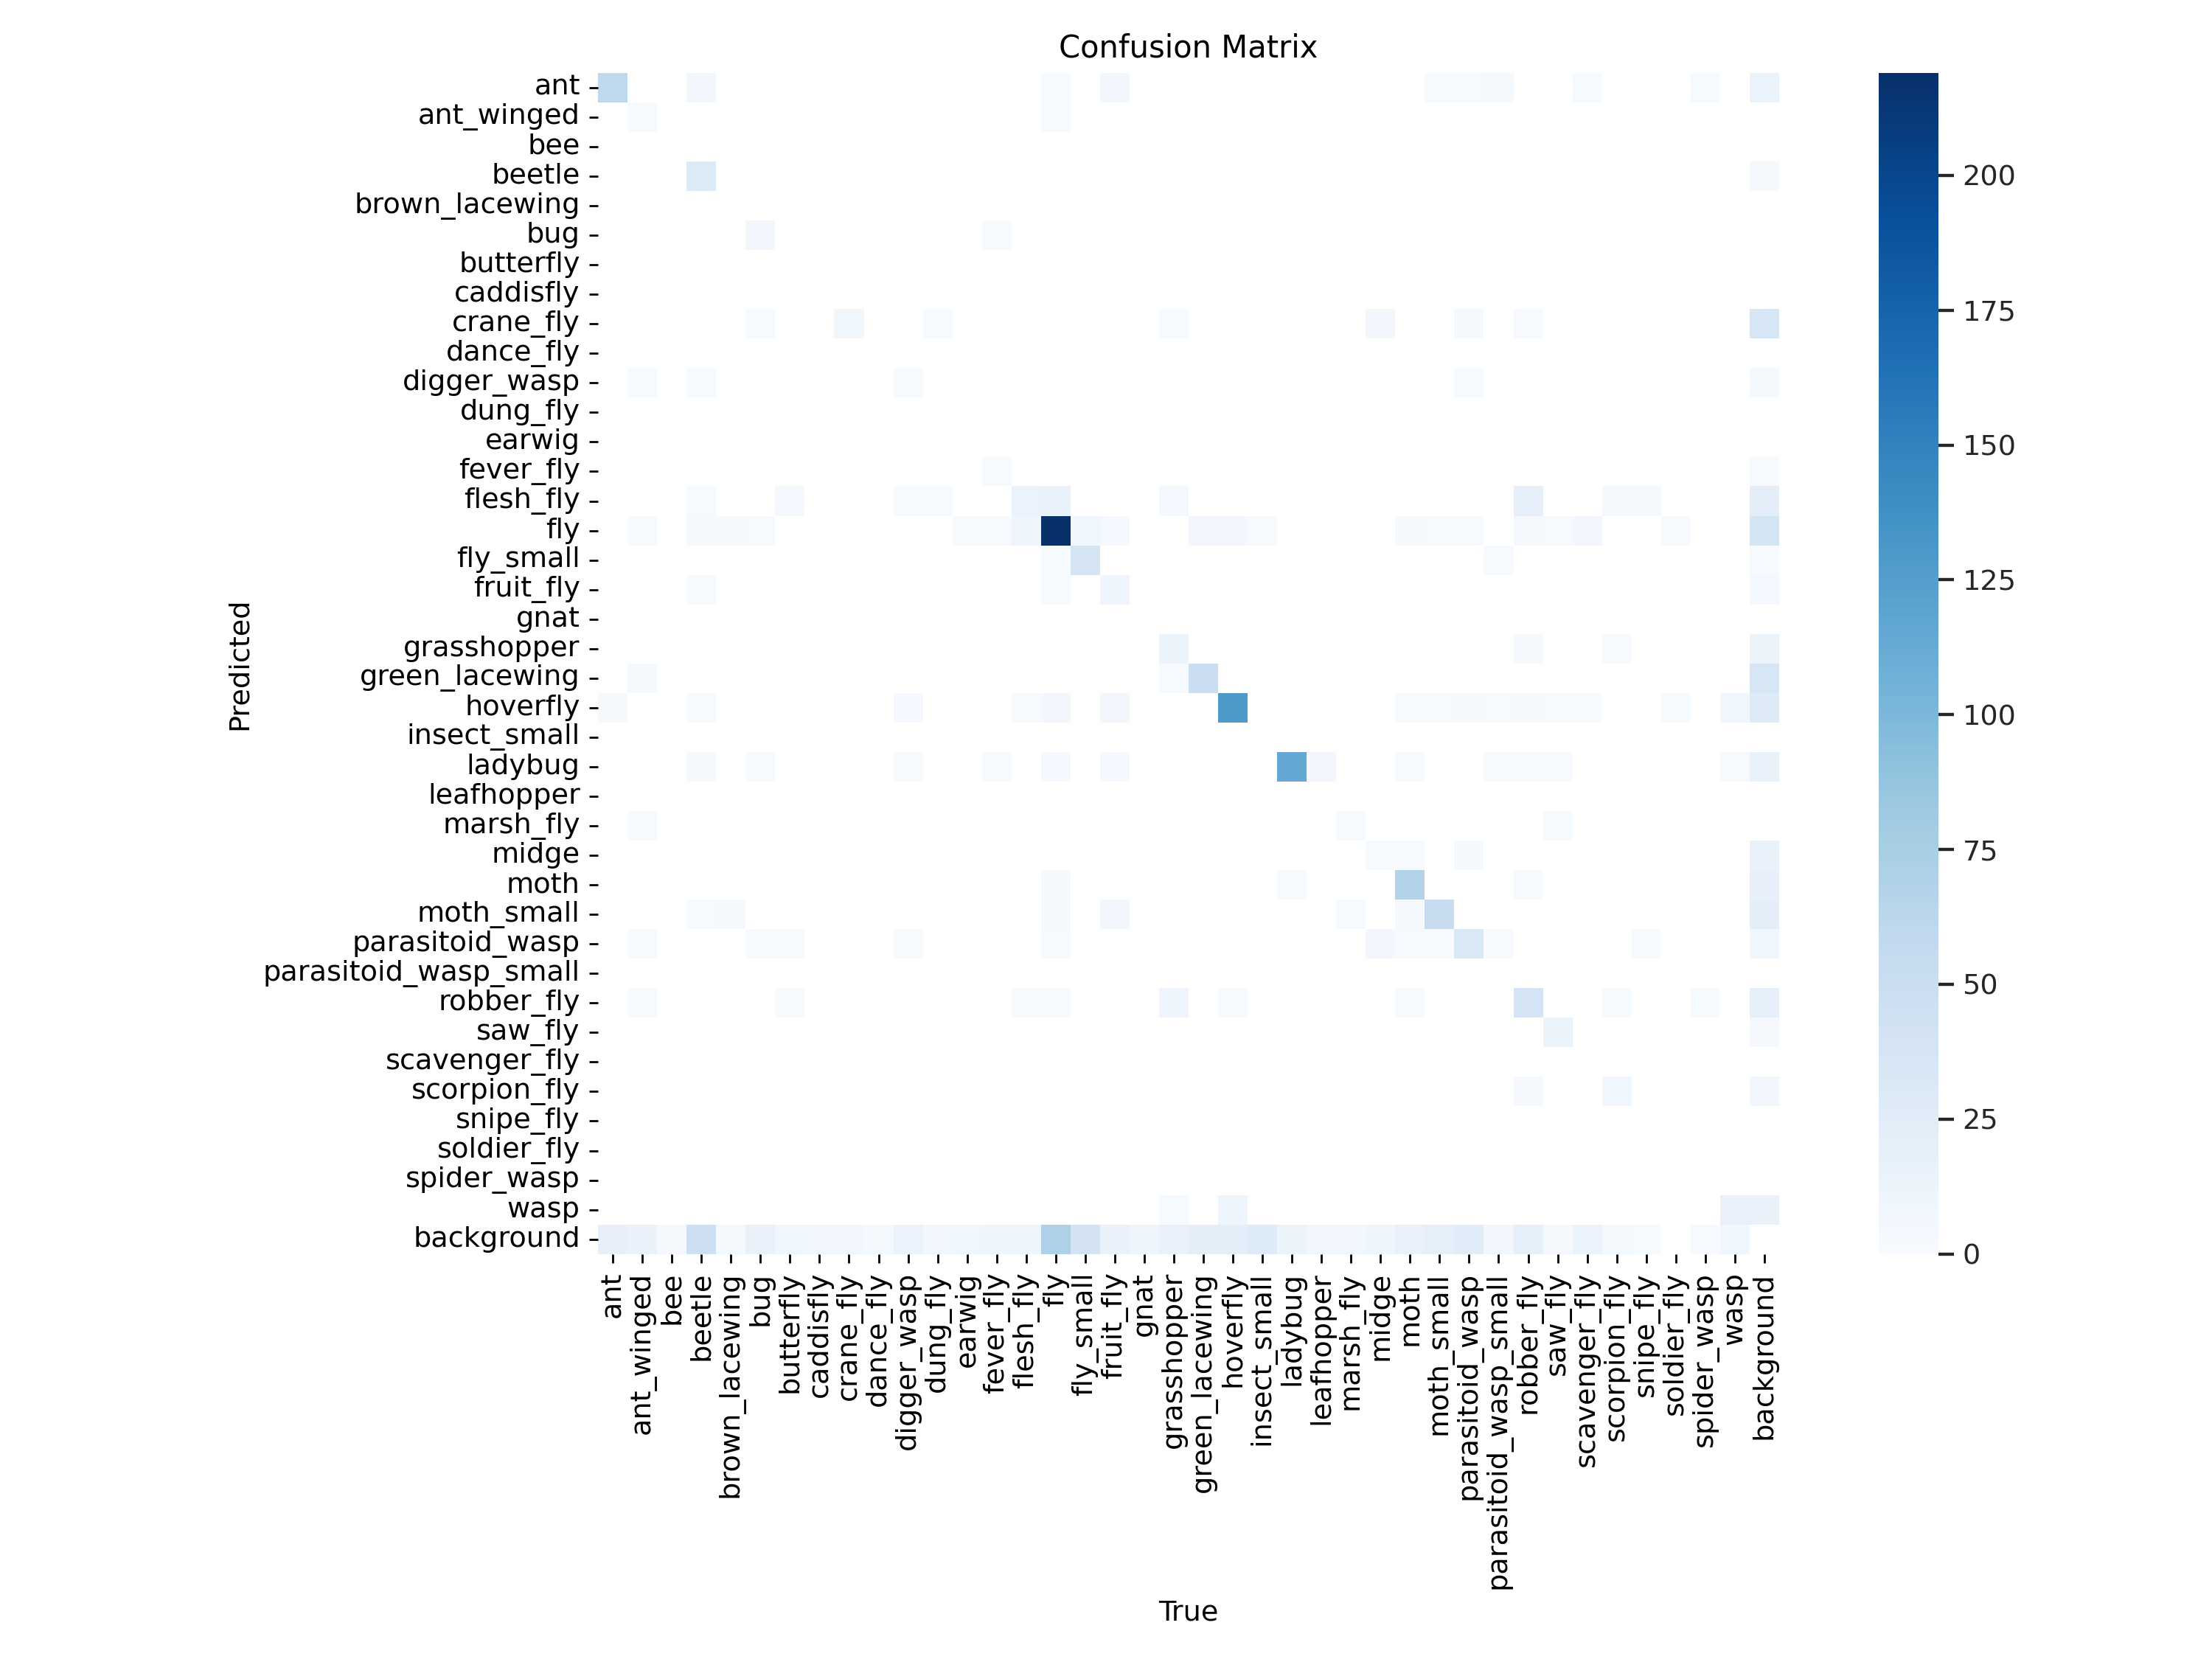

In [ ]:
import os
from IPython.display import Image

# Define the path to the runs directory
runs_dir = f'{HOME}/runs/detect'

# Get the list of run directories and sort them by modification time
run_dirs = sorted([d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))], key=lambda x: os.path.getmtime(os.path.join(runs_dir, x)), reverse=True)

# Get the latest run directory
latest_run_dir = run_dirs[0]

# Define the path to the confusion matrix image in the latest run directory
confusion_matrix_path = os.path.join(runs_dir, latest_run_dir, 'confusion_matrix.png')

# Display the confusion matrix image
print(confusion_matrix_path)
Image(filename=confusion_matrix_path, width=600)

/content
/content/runs/detect/train2/results.png


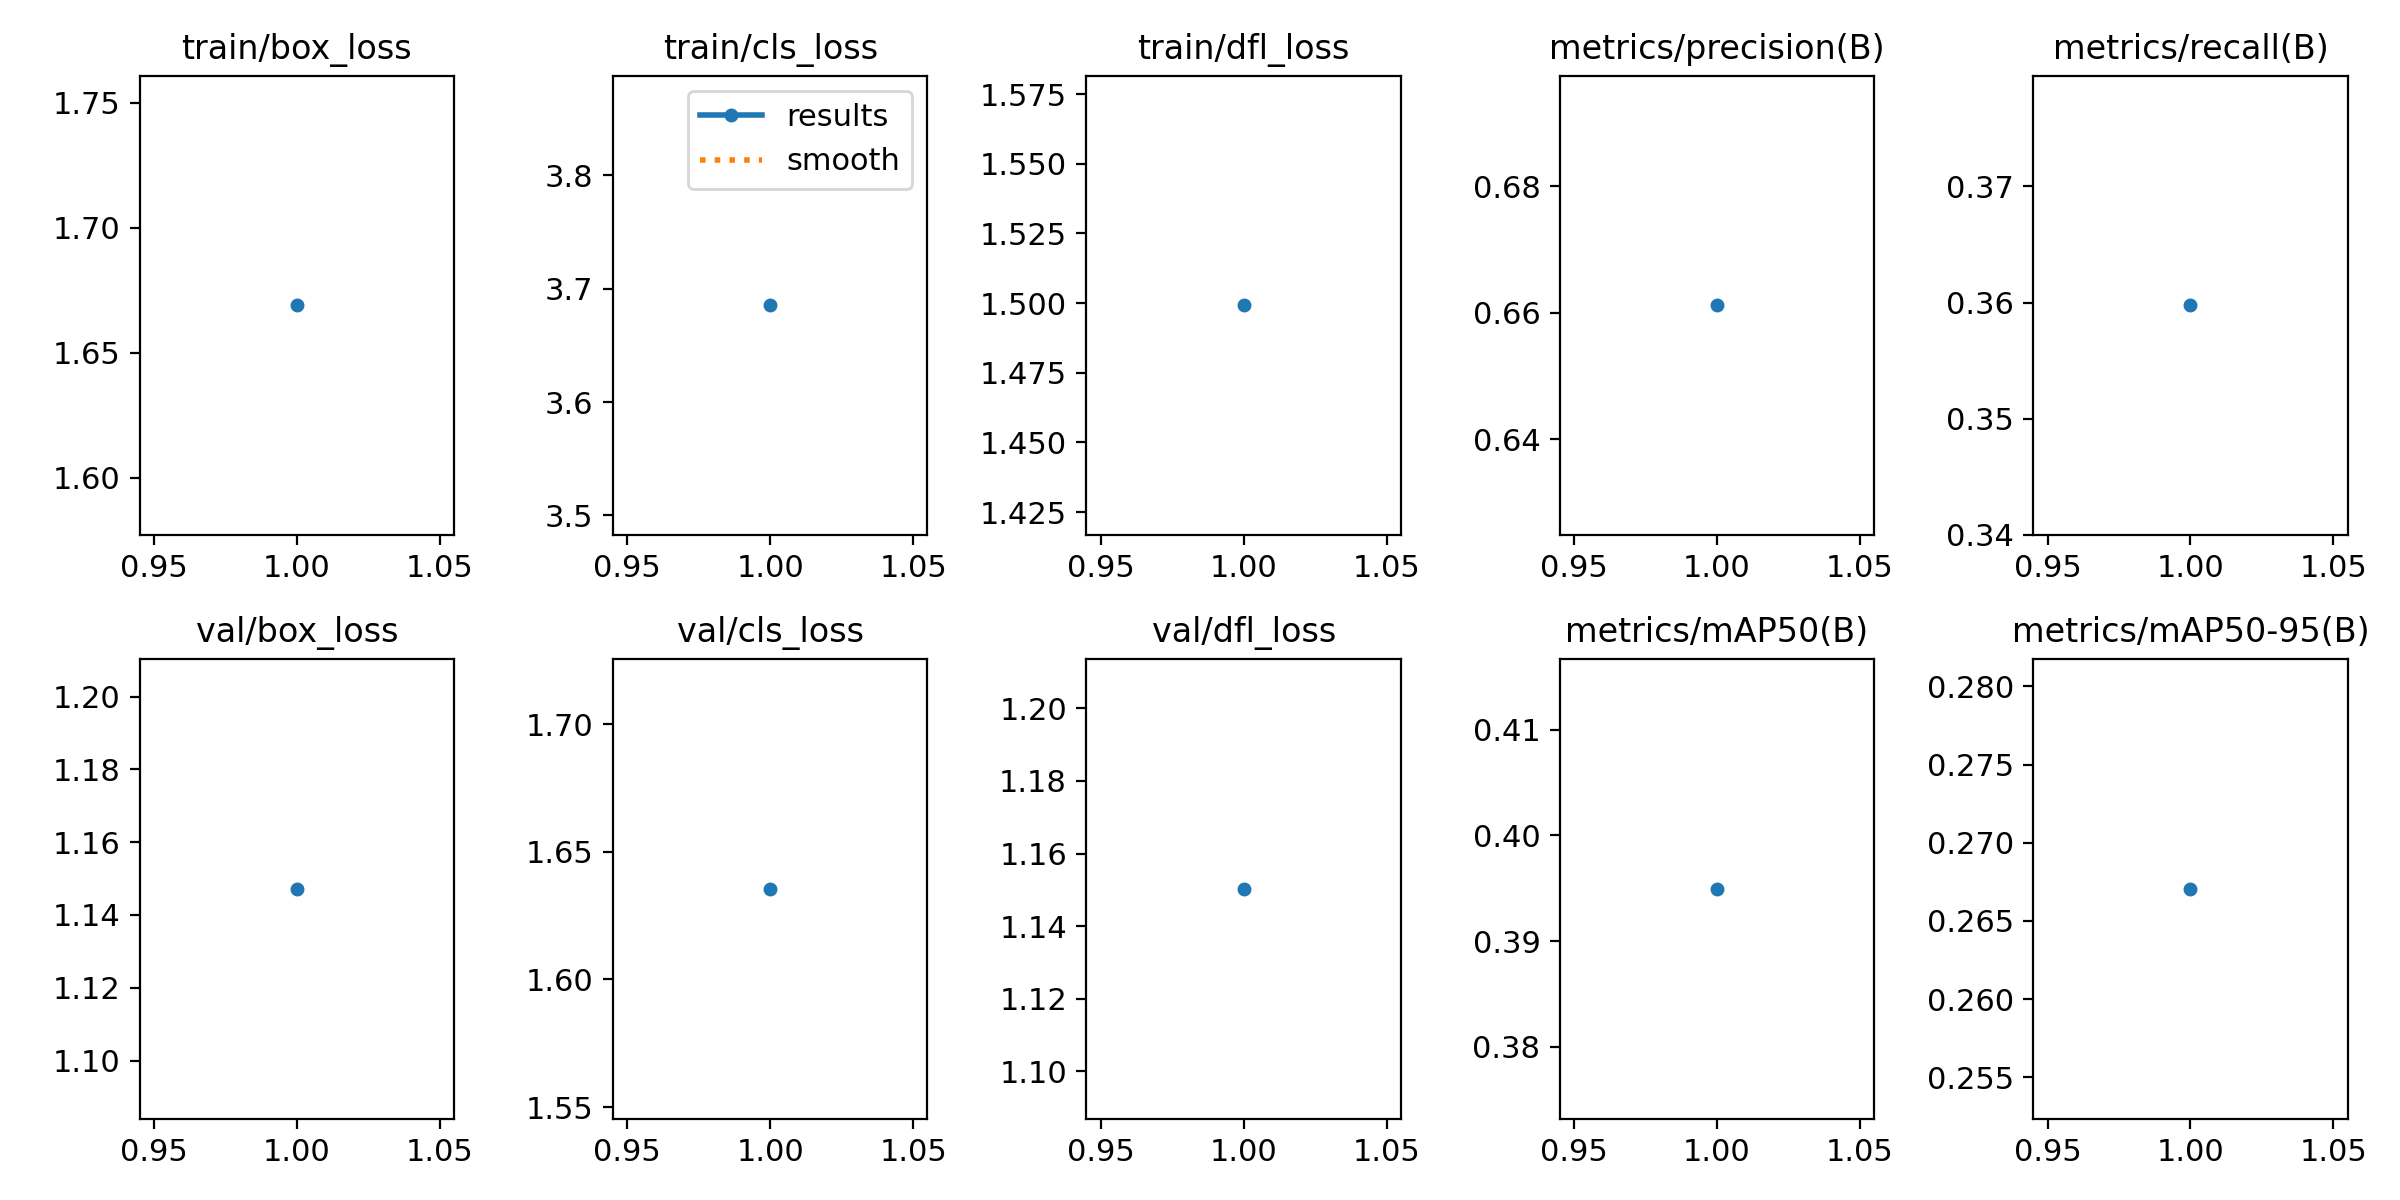

In [ ]:
import os
from IPython.display import Image

# Change directory to HOME
%cd {HOME}

# Define the path to the results image in the latest run directory
results_image_path = os.path.join(runs_dir, latest_run_dir, 'results.png')

# Display the results image
print(results_image_path)
Image(filename=results_image_path, width=600)

/content
/content/runs/detect/train2/val_batch0_pred.jpg


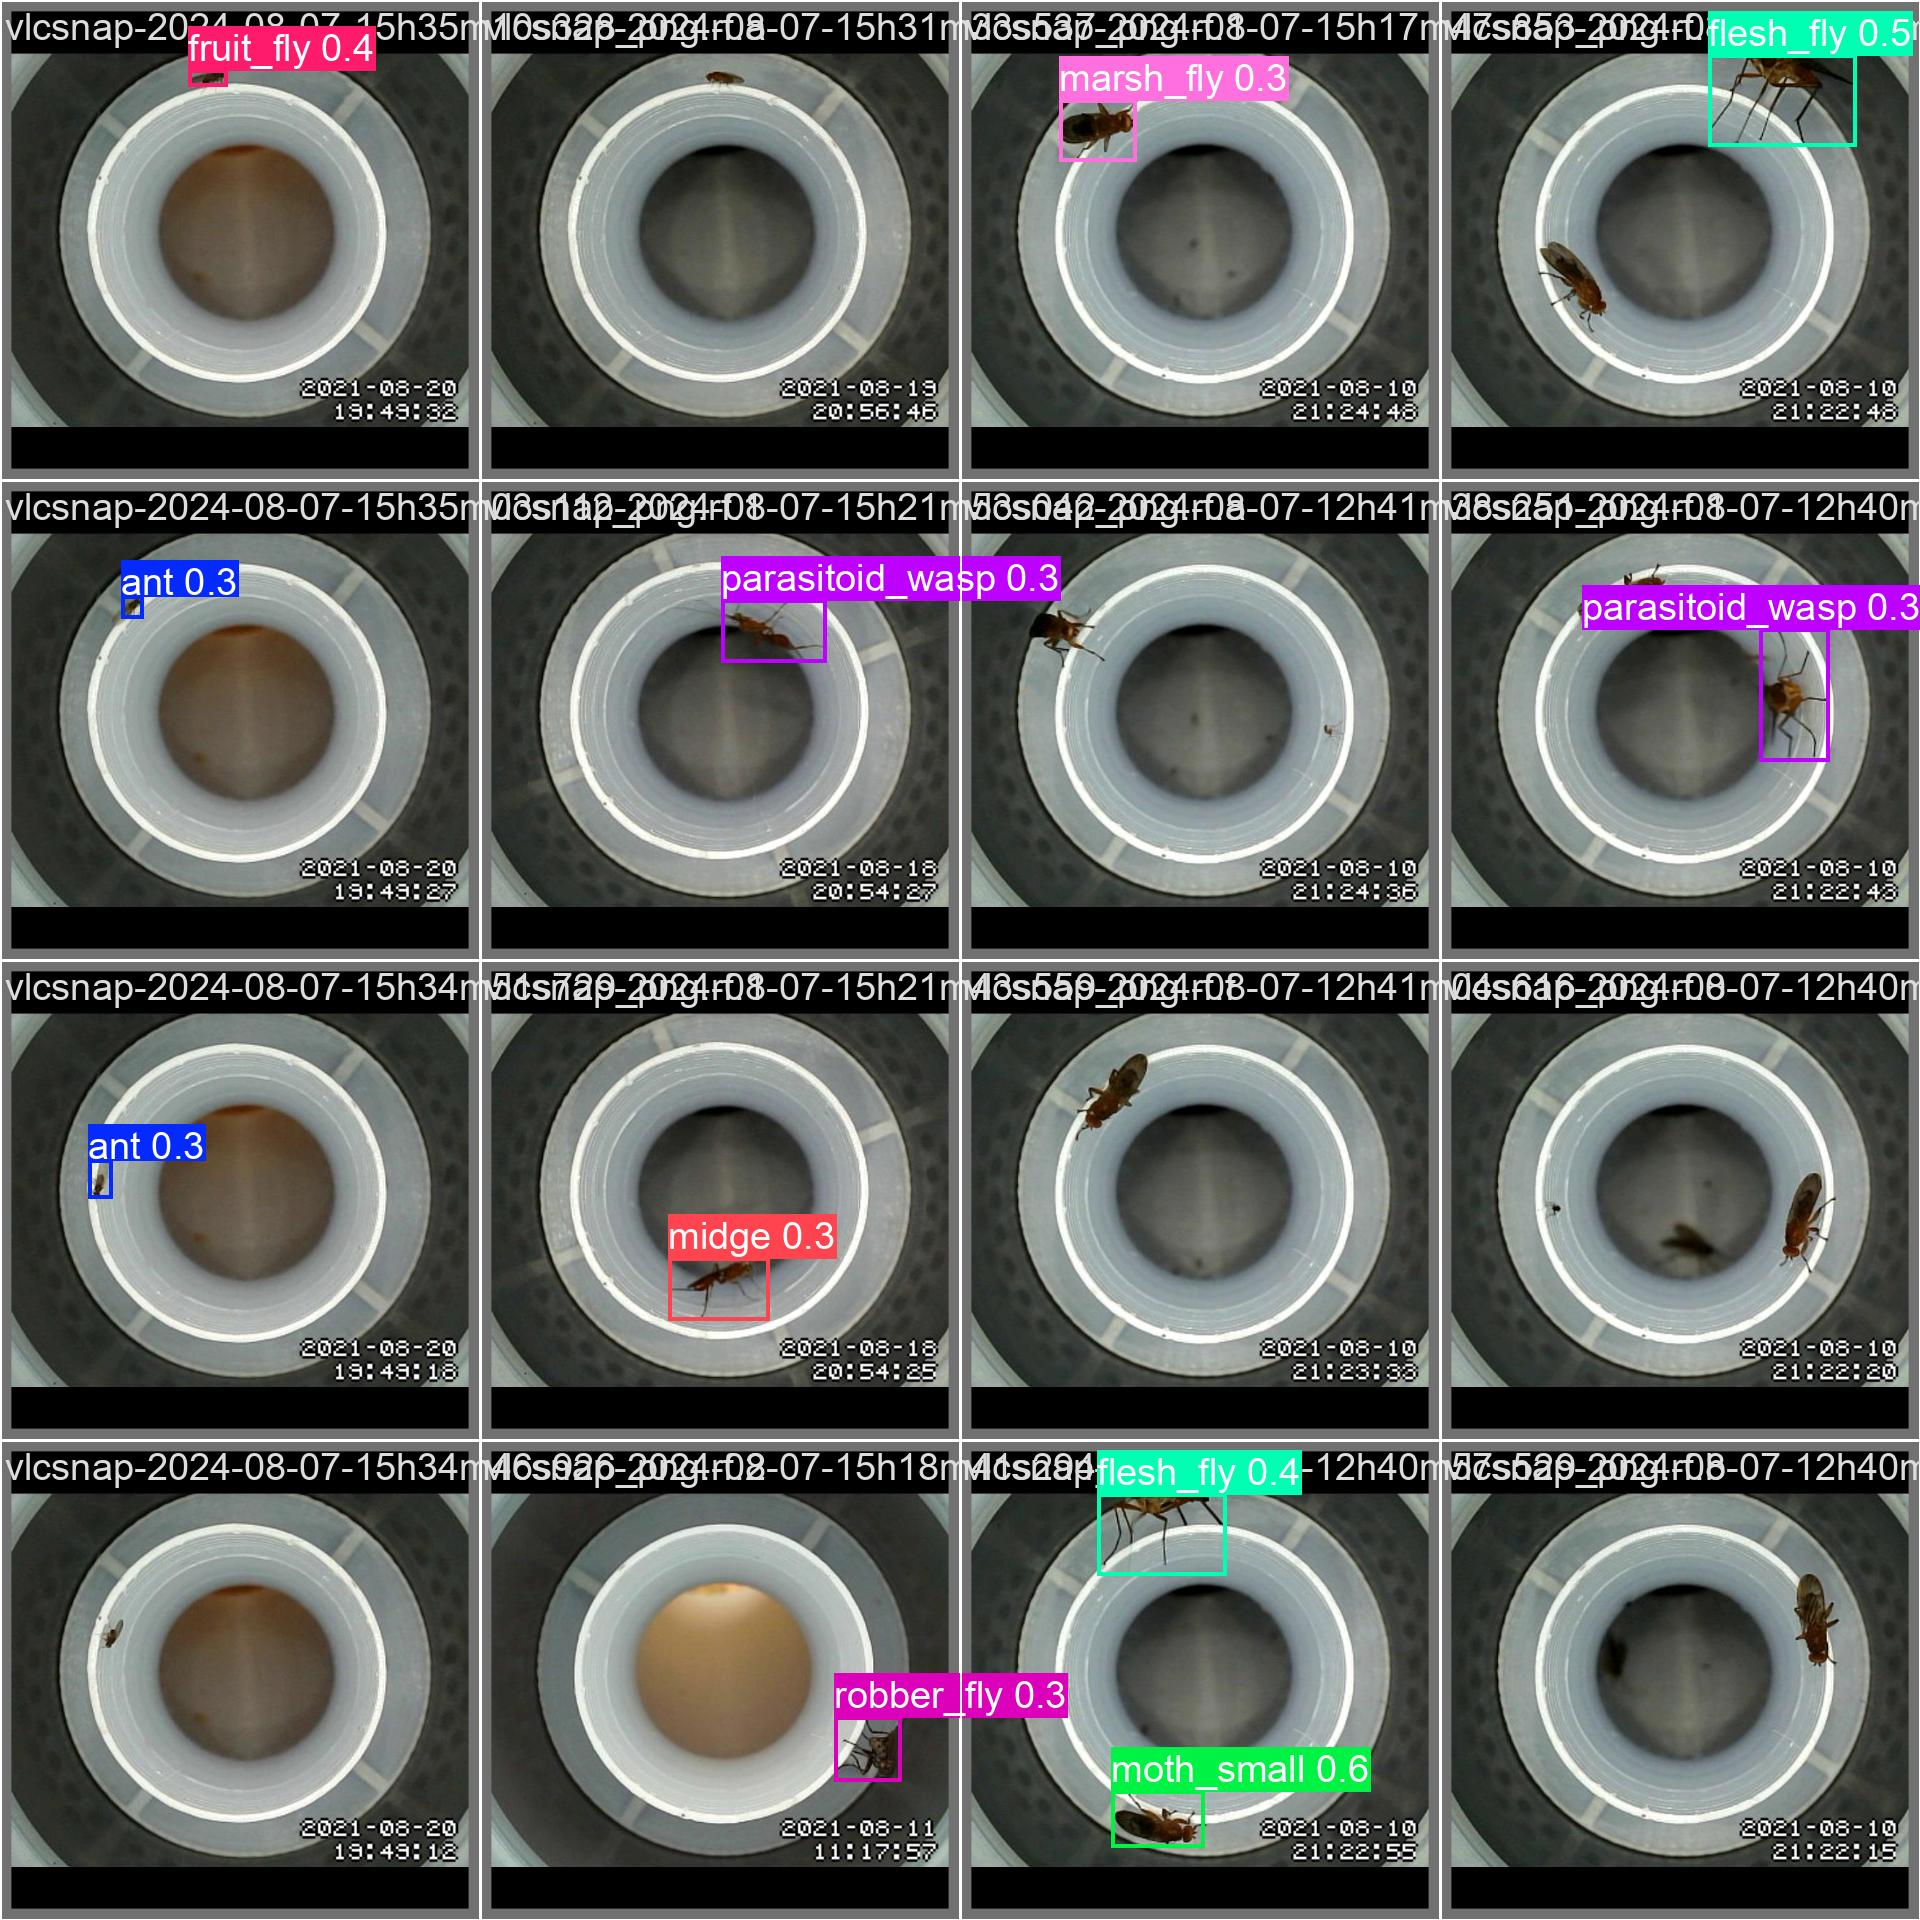

In [ ]:
import os
from IPython.display import Image

# Change directory to HOME
%cd {HOME}

# Define the path to the results image in the latest run directory
val_batch0_pred_path = os.path.join(runs_dir, latest_run_dir, 'val_batch0_pred.jpg')

# Display the results image
print(val_batch0_pred_path)
Image(filename=val_batch0_pred_path, width=600)

## Validate Custom Model

In [ ]:
import os

%cd {HOME}

model_path = os.path.join(runs_dir, latest_run_dir, 'weights/best.pt')
dataset_location = f'{HOME}/datasets/FAIR-D_V2.5-1'

!yolo task=detect mode=val model={model_path} data={dataset_location}/data.yaml



/content
Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,140,677 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/datasets/FAIR-D_V2.5-2/valid/labels.cache... 1794 images, 295 backgrounds, 0 corrupt: 100% 1794/1794 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 113/113 [00:23<00:00,  4.80it/s]
                   all       1794       1849      0.662      0.359      0.393      0.266
                   ant         81         82      0.457       0.78      0.682      0.332
            ant_winged         26         26      0.385      0.121      0.311      0.214
                   bee          3          3          1          0      0.671      0.602
                beetle         98         98      0.724      0.536      0.701      0.441
        brown_lacewing         11         11          1          0     0.0769     0.0297
                   bug  

## Inference with Custom Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=predict model={model_path} conf=0.25 source={dataset_location}/test/images

/content
Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,140,677 parameters, 0 gradients, 28.5 GFLOPs

image 1/909 /content/datasets/FAIR-D_V2.5-2/test/images/14-01-18-avi-2024-11-06-13h45m22s283_png.rf.fd1c491b0c011e05ea308f40766971dc.jpg: 640x640 1 hoverfly, 16.0ms
image 2/909 /content/datasets/FAIR-D_V2.5-2/test/images/14-01-18-avi-2024-11-06-13h45m40s108_png.rf.a79d95c09c7b64cb7a03af083b84d2ee.jpg: 640x640 1 parasitoid_wasp, 16.1ms
image 3/909 /content/datasets/FAIR-D_V2.5-2/test/images/14-01-18-avi-2024-11-06-13h45m54s575_png.rf.1c9b1c32e5fde3a8d45539494c008f89.jpg: 640x640 1 scorpion_fly, 16.0ms
image 4/909 /content/datasets/FAIR-D_V2.5-2/test/images/14-01-18-avi-2024-11-06-13h45m58s629_png.rf.3b3f2605eff823034900ac7a813b7788.jpg: 640x640 1 scorpion_fly, 16.0ms
image 5/909 /content/datasets/FAIR-D_V2.5-2/test/images/15-24-48-mp4-2024-11-05-10h32m30s905_png.rf.11fa109338c5d1c767c79847c7ce88ad.jpg: 640x640 (no d

**NOTE:** Let's take a look at few results.

Found 909 images


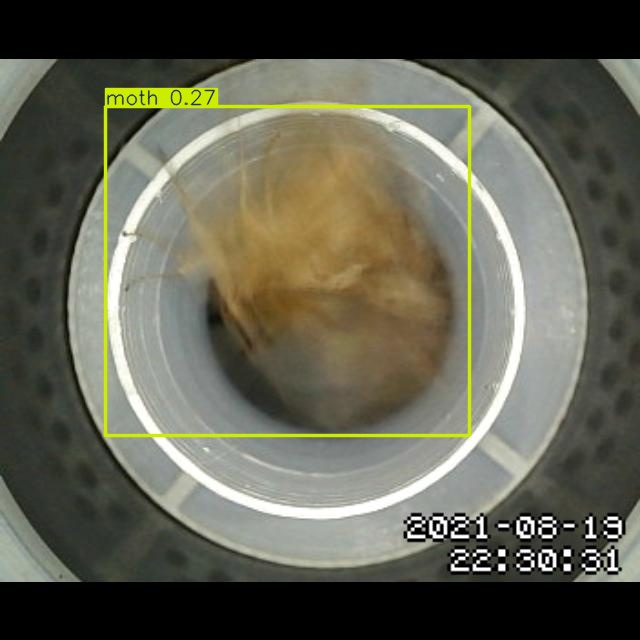

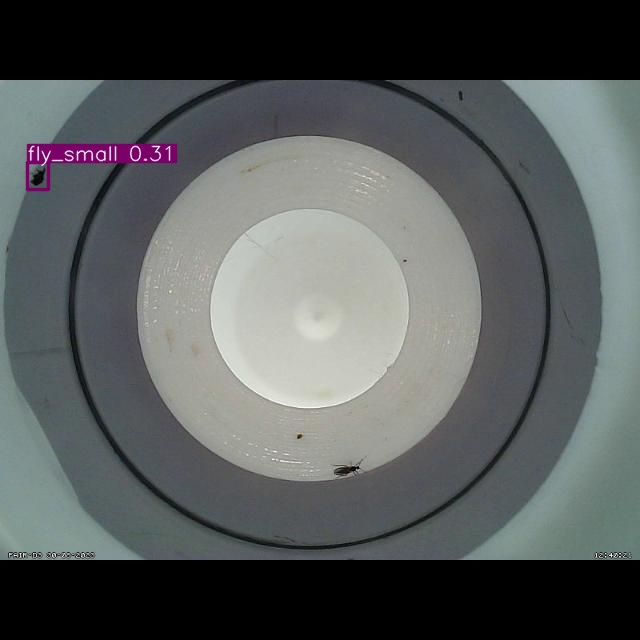

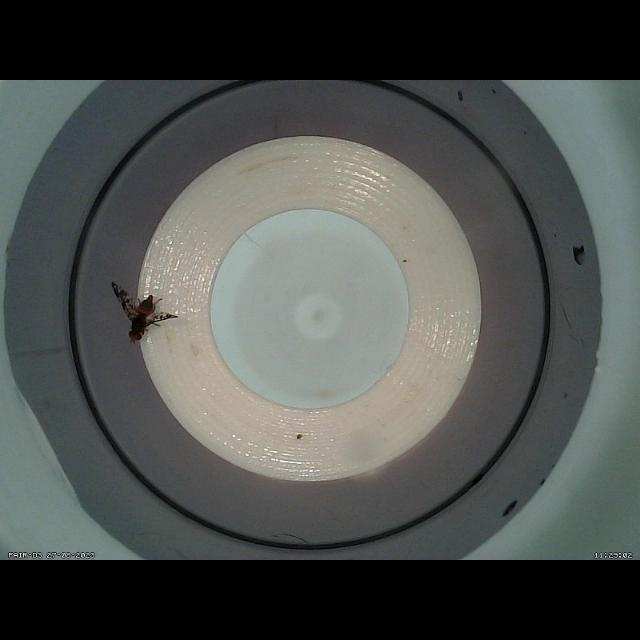

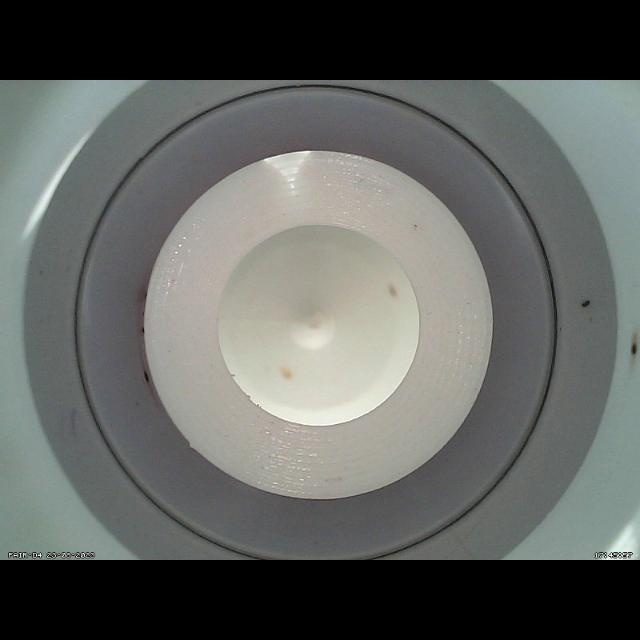

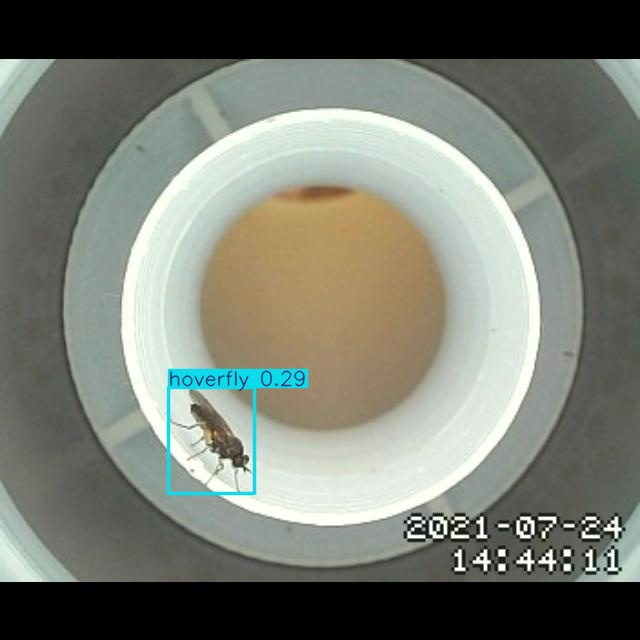

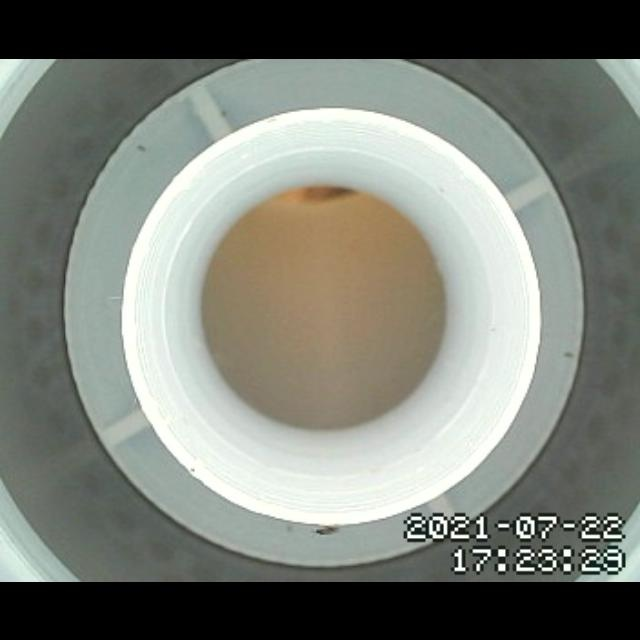

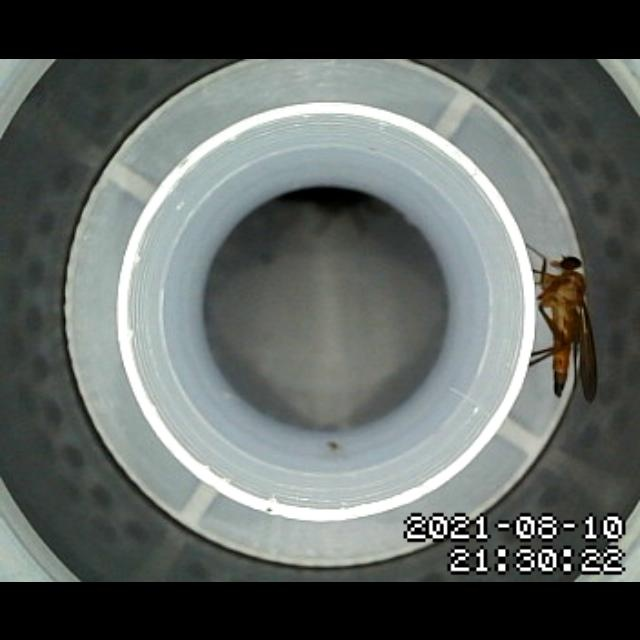

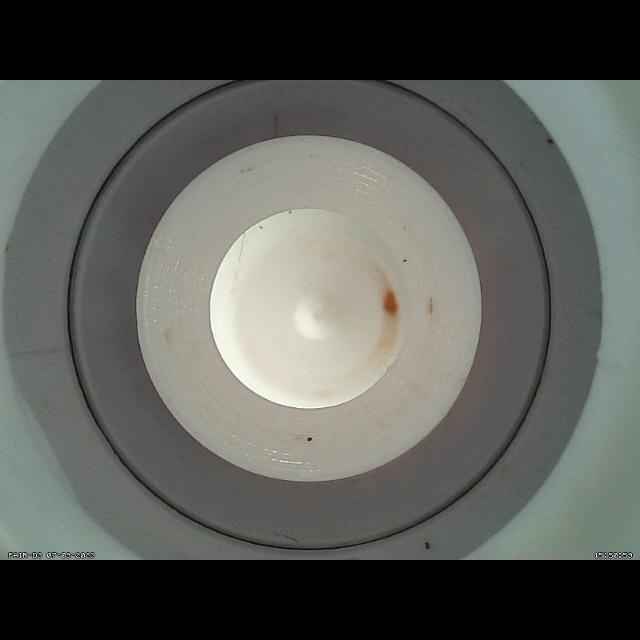

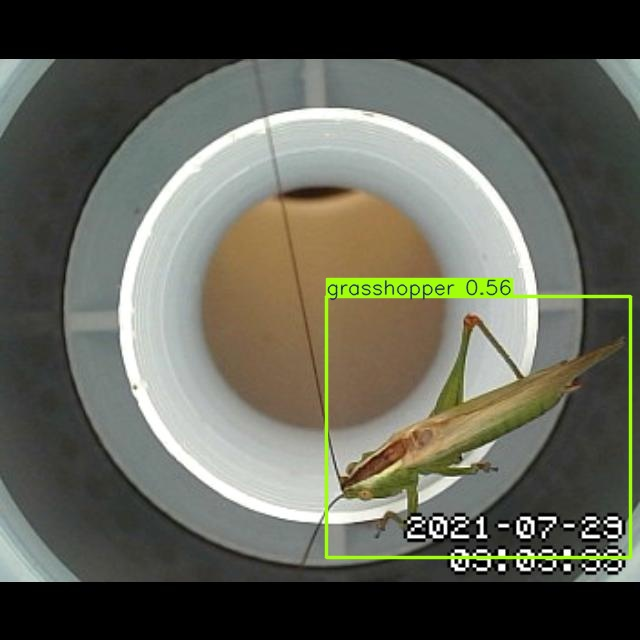

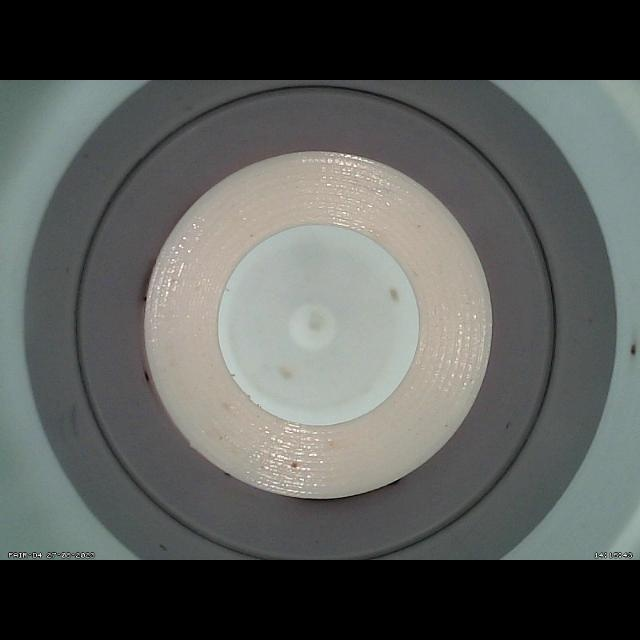

In [ ]:
import glob
from IPython.display import Image, display

# Glob for image files
image_paths = glob.glob(f'{HOME}/runs/detect/predict/*.jpg')
print(f"Found {len(image_paths)} images")

for image_path in glob.glob(f'{HOME}/runs/detect/predict/*.jpg')[:10]:
      display(Image(filename=image_path, width=600))
      print("\n")

# Zip runs and datasets for exporting

In [ ]:
import os
import zipfile
from IPython.display import FileLink

def zip_folder(folder_path):
    # Extract the last part of the folder path to use as the zip file name
    zip_name = os.path.basename(folder_path.strip('/')) + '.zip'

    # Create a zip file
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Walk through the folder
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                # Create the full file path
                file_path = os.path.join(root, file)
                # Add file to the zip file
                zipf.write(file_path, os.path.relpath(file_path, folder_path))

    return zip_name

# Define the folders to zip
folders_to_zip = [f'{HOME}/runs', f'{HOME}/datasets']

# Zip each folder and create download links
for folder in folders_to_zip:
    zip_name = zip_folder(folder)
    display(FileLink(zip_name))


/content/runs.zip

/content/datasets.zip

## Deploy model on Roboflow

Once you have finished training your YOLOv8 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv8 weights.

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [ ]:
!pip install ultralytics==8.0.196

In [ ]:
import os
from roboflow import Roboflow

# Your Roboflow project data
rf = Roboflow(api_key="XXXX") # A private key that is tied to your Roboflow account
project = rf.workspace("fairdevice-zetpx").project("fair-d_v2.5-ki4ty")
version = project.version(1)


# Deploy your model
version.deploy(model_type="yolov8", model_path=f'{HOME}/runs/detect/train9')

loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.3.51, to fix: `pip install ultralytics==8.0.196`


Would you like to continue with the wrong version of ultralytics? y/n:  y


View the status of your deployment at: https://app.roboflow.com/fairdevice-htj8d/fair-d_v2.5/2
Share your model with the world at: https://universe.roboflow.com/fairdevice-htj8d/fair-d_v2.5/model/2


In [ ]:
#project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train/")

In [ ]:
'''#Run inference on your model on a persistant, auto-scaling, cloud API

#load model
model = project.version(dataset.version).model

#choose random test set image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()
pred'''

'#Run inference on your model on a persistant, auto-scaling, cloud API\n\n#load model\nmodel = project.version(dataset.version).model\n\n#choose random test set image\nimport os, random\ntest_set_loc = dataset.location + "/test/images/"\nrandom_test_image = random.choice(os.listdir(test_set_loc))\nprint("running inference on " + random_test_image)\n\npred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()\npred'